# CNN Image Classification

Dataset: Intel Image Classification

In [1]:
%matplotlib inline
import itertools
import json
import os
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {[g.name for g in tf.config.list_physical_devices('GPU')]}")

2026-05-16 11:14:47.376589: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778930087.559452      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778930087.609807      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778930088.054471      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778930088.054517      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778930088.054520      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: ['/physical_device:GPU:0']


## Setup GitHub Repo

In [ ]:
def setup_private_github_repo(token: str, repo_url: str, branch: str = "main") -> Path:
    """clone repo dengan autentikasi x-access-token dan tambahkan ke sys.path"""
    repo_name = repo_url.rstrip("/").split("/")[-1].removesuffix(".git")
    work_dir = Path("/kaggle/working") / repo_name
    if not work_dir.exists():
        auth_url = repo_url.replace("https://", f"https://x-access-token:{token}@")
        subprocess.run(["git", "clone", "--branch", branch, auth_url, str(work_dir)], check=True)
    subprocess.run(["git", "pull", "--ff-only"], cwd=work_dir, check=True)
    if str(work_dir) not in sys.path:
        sys.path.insert(0, str(work_dir))
    return work_dir

In [ ]:
REPO_URL = "https://github.com/buege-putra/ooooo.git"

def _get_github_token() -> str:
    try:
        from kaggle_secrets import UserSecretsClient  # type: ignore
        return UserSecretsClient().get_secret("GITHUB_TOKEN")
    except Exception:
        return os.environ.get("GITHUB_TOKEN", "")

GITHUB_TOKEN = _get_github_token()

if GITHUB_TOKEN:
    REPO_DIR = setup_private_github_repo(GITHUB_TOKEN, REPO_URL)
    print(f"Repo directory: {REPO_DIR}")
else:
    # fallback untuk run lokal
    REPO_DIR = Path(".").resolve().parent
    if str(REPO_DIR) not in sys.path:
        sys.path.insert(0, str(REPO_DIR))
    print(f"Running locally. Repo directory: {REPO_DIR}")

Cloning into '/kaggle/working/ooooo'...


Already up to date.
Repo directory: /kaggle/working/ooooo


In [4]:
from src.cnn.data import (
    load_split, discover_class_names,
    iter_class_image_paths, make_tf_dataset,
)
from src.cnn.evaluate import predict_keras, predict_numpy, evaluation_record
from src.cnn.keras_models import build_conv_cnn, build_locally_connected_cnn
from src.cnn.model import from_keras_model
from src.common.metrics import macro_f1_score, timer
from src.common.plotting import plot_loss_history, plot_metric_bar
from src.common.serialization import save_json, save_history, load_history

print("Imports OK")

Imports OK


## Constants dan Directory

In [5]:
IMG_SIZE = (150, 150)
IMG_SIZE_LC = (64, 64)
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 6
CLASS_NAMES = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
SEED = 42

DENSE_UNITS = 128
DROPOUT_RATE = 0.5
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 1e-3
HEAD = "flatten"

ARTIFACTS_DIR = REPO_DIR / "artifacts" / "cnn"
MODELS_DIR = ARTIFACTS_DIR / "models"
HISTORIES_DIR = ARTIFACTS_DIR / "histories"
REPORTS_DIR = ARTIFACTS_DIR / "reports"

for d in [MODELS_DIR, HISTORIES_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Artifacts directory: {ARTIFACTS_DIR}")

Artifacts directory: /kaggle/working/ooooo/artifacts/cnn


## Dataset

In [ ]:
def _find_intel_dataset() -> tuple[Path, Path]:
    """detect path dataset intel image classification"""
    # Kaggle dataset input
    kaggle_base = Path("/kaggle/input/intel-image-classification")
    if kaggle_base.exists():
        train_dir = kaggle_base / "seg_train" / "seg_train"
        test_dir = kaggle_base / "seg_test" / "seg_test"
        if train_dir.exists():
            return train_dir, test_dir
        
    # download
    import kagglehub  # type: ignore
    path = Path(kagglehub.dataset_download("puneet6060/intel-image-classification"))
    candidates = list(path.rglob("seg_train"))
    if candidates:
        train_dir = candidates[0] / "seg_train"
        test_dir = candidates[0].parent / "seg_test" / "seg_test"
        return train_dir, test_dir
    raise FileNotFoundError(f"Dataset not found under {path}")

TRAIN_DIR, TEST_DIR = _find_intel_dataset()
print(f"Train: {TRAIN_DIR}")
print(f"Test:  {TEST_DIR}")
print(f"Classes: {discover_class_names(TRAIN_DIR)}")

Train: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
Test:  /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test
Classes: ('buildings', 'forest', 'glacier', 'mountain', 'sea', 'street')


In [ ]:
# kumpulkan semua path dan label dari train_dir
all_entries = list(iter_class_image_paths(TRAIN_DIR, class_names=CLASS_NAMES))
all_paths = [str(p) for p, _ in all_entries]
all_labels = np.array([lbl for _, lbl in all_entries], dtype=np.int64)

# split 80/20
n_total = len(all_paths)
n_val = int(n_total * 0.2)
rng_split = np.random.default_rng(SEED)
perm = rng_split.permutation(n_total)
val_idx = perm[:n_val]
train_idx = perm[n_val:]

train_paths = [all_paths[i] for i in train_idx]
train_labels = all_labels[train_idx]
val_paths = [all_paths[i] for i in val_idx]
val_labels = all_labels[val_idx]

tf.random.set_seed(SEED)

train_ds = make_tf_dataset(
    train_paths, train_labels, IMG_SIZE, BATCH_SIZE,
    shuffle=True, seed=SEED, augment=True,
)
val_ds = make_tf_dataset(val_paths, val_labels, IMG_SIZE, BATCH_SIZE, shuffle=False)

print(f"Train samples : {len(train_paths)}")
print(f"Val samples   : {len(val_paths)}")
print(f"Augmentation  : flip, rotation, zoom, translation")

I0000 00:00:1778930175.614077      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Train samples : 11228
Val samples   : 2806
Augmentation  : flip, rotation, zoom, translation


In [8]:
# load test set ke numpy array
print("Loading test set into numpy arrays...")
t0 = time.perf_counter()
test_split = load_split(TEST_DIR, target_size=IMG_SIZE, class_names=CLASS_NAMES)
test_images = test_split.images    # (N, 150, 150, 3), float32
test_labels = test_split.labels    # (N,), int64
print(f"Test images shape: {test_images.shape}, labels shape: {test_labels.shape}")
print(f"Loaded in {time.perf_counter() - t0:.1f}s")

Loading test set into numpy arrays...
Test images shape: (3000, 150, 150, 3), labels shape: (3000,)
Loaded in 23.1s


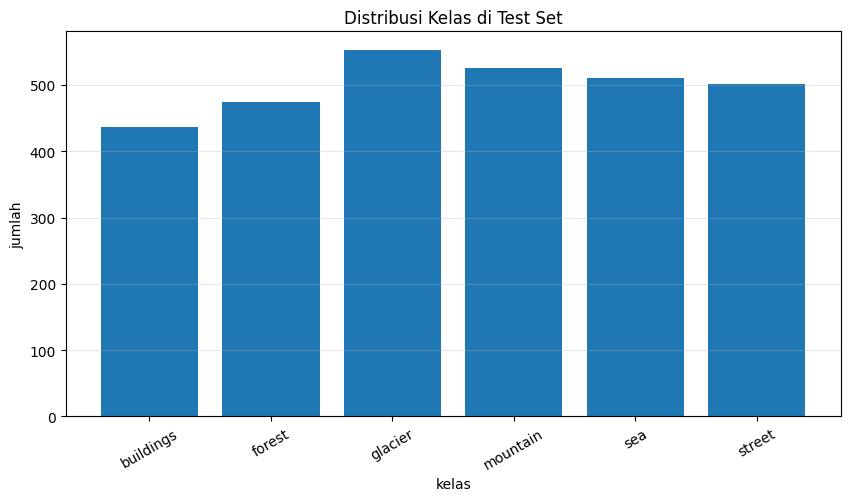

In [9]:
unique, counts = np.unique(test_labels, return_counts=True)
class_dist_records = [
    {"kelas": CLASS_NAMES[i], "jumlah": int(c)}
    for i, c in zip(unique, counts)
]
fig = plot_metric_bar(
    class_dist_records, x="kelas", y="jumlah",
    title="Distribusi Kelas di Test Set",
    save_path=str(REPORTS_DIR / "class_distribution.png"),
    rotation=30,
)
plt.show()

## Eksperimen 1: Training 16 Model Conv2D Shared-Parameter

Grid eksperimen:

- Jumlah layer konvolusi: `[3, 4]`
- Banyak filter per layer: `[32, 64, 128]` dan `[32, 64, 128, 256]` (dipotong sesuai jumlah layer)
- Ukuran kernel: `[3, 5]`
- Jenis pooling: `["max", "average"]`

Batch size 32, epoch maksimum 30, dense 128, dropout 0.5.

Total: 2 x 2 x 2 x 2 = 16 model

In [10]:
import gc

training_results = []

CONV_LAYER_OPTIONS = [3, 4]
FILTER_SCHEDULE_OPTIONS = ([32, 64, 128, 256], [64, 128, 256, 512])
KERNEL_SIZE_OPTIONS = [3, 5]
POOLING_OPTIONS = ["max", "average"]
EXPERIMENT_GRID = list(itertools.product(
    CONV_LAYER_OPTIONS,
    FILTER_SCHEDULE_OPTIONS,
    KERNEL_SIZE_OPTIONS,
    POOLING_OPTIONS,
))
TOTAL_EXPERIMENTS = len(EXPERIMENT_GRID)

for conv_layers, filter_schedule_template, kernel_size, pooling in EXPERIMENT_GRID:
    filter_schedule = tuple(filter_schedule_template[:conv_layers])
    filters_tag = "-".join(str(value) for value in filter_schedule)
    model_name = f"conv_L{conv_layers}_F{filters_tag}_K{kernel_size}_P{pooling[0]}"
    model_path = MODELS_DIR / f"{model_name}.keras"
    history_path = HISTORIES_DIR / f"{model_name}.json"

    if model_path.exists() and history_path.exists():
        print(f"Skipping {model_name} (checkpoint found)")
        training_results.append({
            "model_name": model_name,
            "conv_layers": conv_layers,
            "filters": list(filter_schedule),
            "filter_schedule": filters_tag,
            "kernel_size": kernel_size,
            "pooling": pooling,
            "dense_units": DENSE_UNITS,
            "dropout_rate": DROPOUT_RATE,
            "learning_rate": LEARNING_RATE,
            "skipped": True,
        })
        continue

    print(f"\n[{len(training_results) + 1}/{TOTAL_EXPERIMENTS}] Training: {model_name}")
    model = build_conv_cnn(
        input_shape=(*IMG_SIZE, 3),
        num_classes=NUM_CLASSES,
        conv_layers=conv_layers,
        filters=filter_schedule,
        kernel_size=kernel_size,
        pooling=pooling,
        head=HEAD,
        dense_units=DENSE_UNITS,
        dropout_rate=DROPOUT_RATE,
        name=model_name,
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            str(model_path), save_best_only=True, monitor="val_accuracy", verbose=0
        ),
        keras.callbacks.EarlyStopping(
            patience=EARLY_STOPPING_PATIENCE, min_delta=EARLY_STOPPING_MIN_DELTA,
            restore_best_weights=True, monitor="val_accuracy",
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1
        ),
    ]

    t0 = time.perf_counter()
    history = model.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS,
        callbacks=callbacks, verbose=1,
    )
    train_time = time.perf_counter() - t0

    save_history(history.history, str(history_path))

    training_results.append({
        "model_name": model_name,
        "conv_layers": conv_layers,
        "filters": list(filter_schedule),
        "filter_schedule": filters_tag,
        "kernel_size": kernel_size,
        "pooling": pooling,
        "dense_units": DENSE_UNITS,
        "dropout_rate": DROPOUT_RATE,
        "learning_rate": LEARNING_RATE,
        "skipped": False,
        "train_time_s": round(train_time, 1),
        "epochs_run": len(history.history["loss"]),
    })
    print(f"Done: {model_name} - {train_time:.0f}s, {len(history.history['loss'])} epochs")

    del model
    gc.collect()

print(f"\nAll {TOTAL_EXPERIMENTS} models done.")


[1/16] Training: conv_L3_F32-64-128_K3_Pm
Epoch 1/30


I0000 00:00:1778930203.144890      85 service.cc:152] XLA service 0x79b738004d30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778930203.144934      85 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778930203.567424      85 cuda_dnn.cc:529] Loaded cuDNN version 91002


  6/351 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.1725 - loss: 2.2410

I0000 00:00:1778930207.138585      85 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.4009 - loss: 1.4785 - val_accuracy: 0.6568 - val_loss: 0.9038 - learning_rate: 0.0010
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.5935 - loss: 1.0365 - val_accuracy: 0.6718 - val_loss: 0.8497 - learning_rate: 0.0010
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.6464 - loss: 0.9320 - val_accuracy: 0.6543 - val_loss: 0.8737 - learning_rate: 0.0010
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.6846 - loss: 0.8375 - val_accuracy: 0.7477 - val_loss: 0.6984 - learning_rate: 0.0010
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.7160 - loss: 0.7666 - val_accuracy: 0.7890 - val_loss: 0.5943 - learning_rate: 0.0010
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - accuracy: 0.7431 - loss: 0.7016 - val_accuracy: 0.7773 - val_loss: 0.6023 - learning_rate: 0.0010
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.7634 - loss: 0.675

## Evaluasi Test Set

In [11]:
eval_records = []

for entry in training_results:
    model_name = entry["model_name"]
    model_path = MODELS_DIR / f"{model_name}.keras"
    history_path = HISTORIES_DIR / f"{model_name}.json"

    if not model_path.exists():
        print(f"Model not found: {model_name}")
        continue

    model = keras.models.load_model(str(model_path))

    # val macro F1
    y_val_pred = np.argmax(model.predict(val_ds, verbose=0), axis=-1)
    val_f1 = macro_f1_score(val_labels, y_val_pred)

    # test macro F1
    y_test_pred = predict_keras(model, test_images, batch_size=BATCH_SIZE)

    # history untuk epoch count
    hist = load_history(str(history_path)) if history_path.exists() else {}
    n_epochs = len(hist.get("loss", []))
    best_val_acc = max(hist.get("val_accuracy", [np.nan]))

    record = evaluation_record(
        model_name=model_name,
        y_true=test_labels,
        y_pred=y_test_pred,
        model=model,
    )
    record["test_macro_f1"] = record.pop("macro_f1")
    record.update({
        "conv_layers": entry["conv_layers"],
        "filters": entry["filters"],
        "filter_schedule": entry["filter_schedule"],
        "kernel_size": entry["kernel_size"],
        "pooling": entry["pooling"],
        "dense_units": entry["dense_units"],
        "dropout_rate": entry["dropout_rate"],
        "learning_rate": entry["learning_rate"],
        "val_macro_f1": round(float(val_f1), 4),
        "best_val_accuracy": round(float(best_val_acc), 4),
        "epochs_run": n_epochs,
        "train_time_s": entry.get("train_time_s"),
    })
    eval_records.append(record)
    print(f"{model_name:45s}  val_f1={val_f1:.4f}  test_f1={record['test_macro_f1']:.4f}")

results_df = pd.DataFrame(eval_records)
results_df = results_df.sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
summary_cols = [
    "model_name", "conv_layers", "filter_schedule", "kernel_size",
    "pooling", "val_macro_f1", "test_macro_f1", "parameter_count",
]
print("\n" + results_df[summary_cols].to_string(index=False))

conv_L3_F32-64-128_K3_Pm                       val_f1=0.8361  test_f1=0.8452
conv_L3_F32-64-128_K3_Pa                       val_f1=0.8432  test_f1=0.8452
conv_L3_F32-64-128_K5_Pm                       val_f1=0.8617  test_f1=0.8649
conv_L3_F32-64-128_K5_Pa                       val_f1=0.8623  test_f1=0.8566
conv_L3_F64-128-256_K3_Pm                      val_f1=0.8367  test_f1=0.8284
conv_L3_F64-128-256_K3_Pa                      val_f1=0.8601  test_f1=0.8540
conv_L3_F64-128-256_K5_Pm                      val_f1=0.8614  test_f1=0.8588
conv_L3_F64-128-256_K5_Pa                      val_f1=0.8614  test_f1=0.8661
conv_L4_F32-64-128-256_K3_Pm                   val_f1=0.8792  test_f1=0.8794
conv_L4_F32-64-128-256_K3_Pa                   val_f1=0.8630  test_f1=0.8481
conv_L4_F32-64-128-256_K5_Pm                   val_f1=0.8746  test_f1=0.8731
conv_L4_F32-64-128-256_K5_Pa                   val_f1=0.8783  test_f1=0.8706
conv_L4_F64-128-256-512_K3_Pm                  val_f1=0.8755  test_f1=0.8720

In [12]:
results_df.to_csv(str(REPORTS_DIR / "cnn_conv_results.csv"), index=False)
save_json(results_df.to_dict(orient="records"), str(REPORTS_DIR / "cnn_conv_results.json"))
print("Saved cnn_conv_results.csv and .json")
results_df.style.background_gradient(subset=["val_macro_f1", "test_macro_f1"], cmap="YlGn")

Saved cnn_conv_results.csv and .json


,model_name,parameter_count,test_macro_f1,conv_layers,filters,filter_schedule,kernel_size,pooling,dense_units,dropout_rate,learning_rate,val_macro_f1,best_val_accuracy,epochs_run,train_time_s
0,conv_L4_F64-128-256-512_K3_Pa,6860294,0.872313,4,"[64, 128, 256, 512]",64-128-256-512,3,average,128,0.500000,0.001000,0.886700,0.886000,30,564.700000
1,conv_L4_F32-64-128-256_K3_Pm,3043526,0.879375,4,"[32, 64, 128, 256]",32-64-128-256,3,max,128,0.500000,0.001000,0.879200,0.878500,23,437.900000
2,conv_L4_F32-64-128-256_K5_Pa,3733190,0.870597,4,"[32, 64, 128, 256]",32-64-128-256,5,average,128,0.500000,0.001000,0.878300,0.877000,30,565.800000
3,conv_L4_F64-128-256-512_K3_Pm,6860294,0.871971,4,"[64, 128, 256, 512]",64-128-256-512,3,max,128,0.500000,0.001000,0.875500,0.874900,30,566.200000
4,conv_L4_F32-64-128-256_K5_Pm,3733190,0.873067,4,"[32, 64, 128, 256]",32-64-128-256,5,max,128,0.500000,0.001000,0.874600,0.874200,29,549.600000
5,conv_L4_F64-128-256-512_K5_Pm,9615878,0.863730,4,"[64, 128, 256, 512]",64-128-256-512,5,max,128,0.500000,0.001000,0.867900,0.867400,26,505.700000
6,conv_L4_F64-128-256-512_K5_Pa,9615878,0.869087,4,"[64, 128, 256, 512]",64-128-256-512,5,average,128,0.500000,0.001000,0.863600,0.862400,27,524.100000
7,conv_L4_F32-64-128-256_K3_Pa,3043526,0.848084,4,"[32, 64, 128, 256]",32-64-128-256,3,average,128,0.500000,0.001000,0.863000,0.862400,21,393.700000
8,conv_L3_F32-64-128_K5_Pa,5567942,0.856607,3,"[32, 64, 128]",32-64-128,5,average,128,0.500000,0.001000,0.862300,0.861400,30,558.800000
9,conv_L3_F32-64-128_K5_Pm,5567942,0.864927,3,"[32, 64, 128]",32-64-128,5,max,128,0.500000,0.001000,0.861700,0.861000,25,469.200000


## Pemilihan Model Shared Terbaik

In [13]:
best_row = results_df.loc[results_df["val_macro_f1"].idxmax()]
best_model_name = best_row["model_name"]
best_n_layers = int(best_row["conv_layers"])
best_filters = list(best_row["filters"])
best_filter_schedule = best_row["filter_schedule"]
best_kernel = int(best_row["kernel_size"])
best_pooling = best_row["pooling"]
best_dense_units = int(best_row["dense_units"])
best_dropout_rate = float(best_row["dropout_rate"])
best_learning_rate = float(best_row["learning_rate"])

print(f"Best shared model : {best_model_name}")
print(f"  conv_layers     : {best_n_layers}")
print(f"  filters         : {best_filter_schedule}")
print(f"  kernel_size     : {best_kernel}")
print(f"  pooling         : {best_pooling}")
print(f"  dense_units     : {best_dense_units}")
print(f"  dropout_rate    : {best_dropout_rate}")
print(f"  learning_rate   : {best_learning_rate:g}")
print(f"  val macro F1    : {best_row['val_macro_f1']:.4f}")
print(f"  test macro F1   : {best_row['test_macro_f1']:.4f}")
print(f"  parameters      : {best_row['parameter_count']:,}")

save_json(best_row.to_dict(), str(REPORTS_DIR / "best_shared_model_info.json"))

best_keras_model = keras.models.load_model(str(MODELS_DIR / f"{best_model_name}.keras"))

Best shared model : conv_L4_F64-128-256-512_K3_Pa
  conv_layers     : 4
  filters         : 64-128-256-512
  kernel_size     : 3
  pooling         : average
  dense_units     : 128
  dropout_rate    : 0.5
  learning_rate   : 0.001
  val macro F1    : 0.8867
  test macro F1   : 0.8723
  parameters      : 6,860,294


## Eksperimen 2: LocallyConnected2D Non-Shared

Konfigurasi utama model non-shared mengikuti model shared terbaik, lalu layer konvolusinya diganti menjadi locally connected tanpa parameter sharing.

Arsitektur LC2D menggunakan input `IMG_SIZE_LC=64` untuk mengurangi waktu komputasi.

In [ ]:
import gc

# clear Keras state to free memory
keras.backend.clear_session()
gc.collect()

# reload best Conv2D model
best_keras_model = keras.models.load_model(str(MODELS_DIR / f"{best_model_name}.keras"))
print(f"Session cleared. Best model reloaded: {best_model_name}")

Session cleared. Best model reloaded: conv_L4_F64-128-256-512_K3_Pa


In [ ]:
# dataset LC2D dibuat pada ukuran yang sama dengan konfigurasi LC
lc_train_ds = make_tf_dataset(train_paths, train_labels, IMG_SIZE_LC, BATCH_SIZE, shuffle=True, seed=SEED, augment=True)
lc_val_ds = make_tf_dataset(val_paths, val_labels, IMG_SIZE_LC, BATCH_SIZE, shuffle=False)
lc_test_split = load_split(TEST_DIR, target_size=IMG_SIZE_LC, class_names=CLASS_NAMES)
lc_test_images = lc_test_split.images
lc_test_labels = lc_test_split.labels

lc2d_model_name = f"lc2d_shared_config_{best_model_name}"
lc2d_weights_path = MODELS_DIR / f"{lc2d_model_name}.weights.h5"
lc2d_history_path = HISTORIES_DIR / f"{lc2d_model_name}.json"

lc2d_keras_model = build_locally_connected_cnn(
    input_shape=(*IMG_SIZE_LC, 3),
    num_classes=NUM_CLASSES,
    conv_layers=best_n_layers,
    filters=best_filters,
    kernel_size=best_kernel,
    pooling=best_pooling,
    head=HEAD,
    dense_units=best_dense_units,
    dropout_rate=best_dropout_rate,
    padding="same",
    name=lc2d_model_name,
)

if lc2d_weights_path.exists() and lc2d_history_path.exists():
    print(f"Skipping {lc2d_model_name} (weights checkpoint found)")
    lc2d_keras_model.load_weights(str(lc2d_weights_path))
    lc2d_history = load_history(str(lc2d_history_path))
else:
    lc2d_keras_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    lc2d_callbacks = [
        keras.callbacks.ModelCheckpoint(
            str(lc2d_weights_path), save_best_only=True, save_weights_only=True,
            monitor="val_accuracy", verbose=0
        ),
        keras.callbacks.EarlyStopping(
            patience=EARLY_STOPPING_PATIENCE, min_delta=EARLY_STOPPING_MIN_DELTA,
            restore_best_weights=True, monitor="val_accuracy",
        ),
    ]
    with timer("lc2d keras training") as lc2d_train_t:
        lc2d_fit_history = lc2d_keras_model.fit(
            lc_train_ds, validation_data=lc_val_ds, epochs=EPOCHS,
            callbacks=lc2d_callbacks, verbose=1,
        )
    lc2d_train_time = lc2d_train_t.seconds
    lc2d_history = lc2d_fit_history.history
    save_history(lc2d_history, str(lc2d_history_path))
    lc2d_keras_model.load_weights(str(lc2d_weights_path))
    print(f"Done: {lc2d_model_name} - {lc2d_train_time:.0f}s")

lc2d_params = lc2d_keras_model.count_params()
shared_params = int(best_row["parameter_count"])

# evaluasi LC2D Keras (untuk perbandingan fair dengan Conv2D Keras)
lc2d_keras_pred = predict_keras(lc2d_keras_model, lc_test_images, batch_size=BATCH_SIZE)
lc2d_keras_f1 = macro_f1_score(lc_test_labels, lc2d_keras_pred)

# evaluasi LC2D NumPy (untuk verifikasi implementasi from scratch)
lc2d_numpy_model = from_keras_model(lc2d_keras_model, name=f"{lc2d_model_name}_numpy")
lc2d_numpy_pred = predict_numpy(lc2d_numpy_model, lc_test_images)
lc2d_numpy_f1 = macro_f1_score(lc_test_labels, lc2d_numpy_pred)

print()
print(f"LC2D Keras parameters        : {lc2d_params:,}")
print(f"Conv2D shared parameters     : {shared_params:,}")
print(f"Rasio (LC2D / shared)        : {lc2d_params / shared_params:.1f}x")
print(f"LC2D Keras test macro F1     : {lc2d_keras_f1:.4f}")
print(f"LC2D NumPy  test macro F1    : {lc2d_numpy_f1:.4f}")
print(f"LC2D Keras vs NumPy agreement: {np.mean(lc2d_keras_pred == lc2d_numpy_pred) * 100:.2f}%")

Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 88ms/step - accuracy: 0.1792 - loss: 1.7918 - val_accuracy: 0.1711 - val_loss: 1.7914
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.1794 - loss: 1.7912 - val_accuracy: 0.1711 - val_loss: 1.7916
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.1803 - loss: 1.7909 - val_accuracy: 0.1711 - val_loss: 1.7917
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.1823 - loss: 1.7903 - val_accuracy: 0.1711 - val_loss: 1.7917
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.1873 - loss: 1.7901 - val_accuracy: 0.1711 - val_loss: 1.7916
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.1775 - loss: 1.7906 - val_accuracy: 0.1711 - val_loss: 1.7917
Done: lc2d_shared_config_conv_L4_F64-128-256-512_K3_Pa - 123s

LC2D Keras parameters        : 235,111,302
Conv2D shared parameters     : 6,860,294
Rasio (LC2D / shared)        : 34.3x
LC2D Keras test macro F1     : 0.049

In [ ]:
lc2d_record = {
    "model_name": lc2d_model_name,
    "type": "non_shared",
    "input_size": f"{IMG_SIZE_LC[0]}x{IMG_SIZE_LC[1]}",
    "conv_layers": best_n_layers,
    "filters": best_filters,
    "filter_schedule": best_filter_schedule,
    "kernel_size": best_kernel,
    "pooling": best_pooling,
    "dense_units": best_dense_units,
    "parameter_count": int(lc2d_params),
    "keras_test_macro_f1": round(float(lc2d_keras_f1), 4),
    "numpy_test_macro_f1": round(float(lc2d_numpy_f1), 4),
}
save_json(lc2d_record, str(REPORTS_DIR / "lc2d_info.json"))
print("Saved lc2d_info.json")


Saved lc2d_info.json


In [ ]:
import gc

# free LC2D models
del lc2d_keras_model, lc2d_numpy_model
gc.collect()
keras.backend.clear_session()

best_keras_model = keras.models.load_model(str(MODELS_DIR / f"{best_model_name}.keras"))
print("LC2D models freed. Best Conv2D model reloaded.")

LC2D models freed. Best Conv2D model reloaded for NumPy evaluation.


## Evaluasi Implementasi NumPy

Model Keras terbaik dikonversi ke implementasi NumPy menggunakan `from_keras_model`.
Prediksi dibandingkan pada test set yang sama.

In [18]:
print(f"Converting {best_model_name} to NumPy model...")
numpy_model = from_keras_model(best_keras_model, name=f"{best_model_name}_numpy")
print(f"NumPy model layers: {len(numpy_model.layers)}")
print(f"NumPy parameter count: {numpy_model.parameter_count():,}")

Converting conv_L4_F64-128-256-512_K3_Pa to NumPy model...
NumPy model layers: 11
NumPy parameter count: 6,860,294


In [19]:
# prediksi Keras (sebagai referensi full test)
with timer("keras full inference") as keras_full_t:
    y_keras = predict_keras(best_keras_model, test_images, batch_size=BATCH_SIZE)
keras_full_time = keras_full_t.seconds
keras_f1 = macro_f1_score(test_labels, y_keras)

# prediksi NumPy pada seluruh split test agar sesuai spesifikasi evaluasi.
with timer("numpy full inference") as numpy_t:
    y_numpy = predict_numpy(numpy_model, test_images)
numpy_time = numpy_t.seconds
numpy_f1 = macro_f1_score(test_labels, y_numpy)

print(f"Keras  (full test, {len(test_images)} samples) : F1={keras_f1:.4f}, time={keras_full_time:.2f}s")
print(f"NumPy  (full test, {len(test_images)} samples) : F1={numpy_f1:.4f}, time={numpy_time:.2f}s")
print(f"Agreement (full test): {np.mean(y_keras == y_numpy) * 100:.2f}%")

Keras  (full test, 3000 samples) : F1=0.8723, time=3.91s
NumPy  (full test, 3000 samples) : F1=0.8723, time=145.94s
Agreement (full test): 100.00%


In [20]:
keras_vs_numpy = {
    "model_name": best_model_name,
    "eval_samples": int(len(test_images)),
    "eval_split": "test",
    "keras_macro_f1_full": round(float(keras_f1), 4),
    "numpy_macro_f1_full": round(float(numpy_f1), 4),
    "keras_full_time_s": round(keras_full_time, 3),
    "numpy_time_s": round(numpy_time, 3),
    "prediction_agreement_pct": round(float(np.mean(y_keras == y_numpy)) * 100, 2),
}
save_json(keras_vs_numpy, str(REPORTS_DIR / "keras_vs_numpy_best_shared.json"))
print("Saved keras_vs_numpy_best_shared.json")
print(json.dumps(keras_vs_numpy, indent=2))


Saved keras_vs_numpy_best_shared.json
{
  "model_name": "conv_L4_F64-128-256-512_K3_Pa",
  "eval_samples": 3000,
  "eval_split": "test",
  "keras_macro_f1_full": 0.8723,
  "numpy_macro_f1_full": 0.8723,
  "keras_full_time_s": 3.909,
  "numpy_time_s": 145.937,
  "prediction_agreement_pct": 100.0
}


## Analisis

### 1. Pengaruh Kedalaman Konvolusi

 conv_layers     mean      std      max      min
           3 0.852400 0.012454 0.866096 0.828412
           4 0.868528 0.009335 0.879375 0.848084


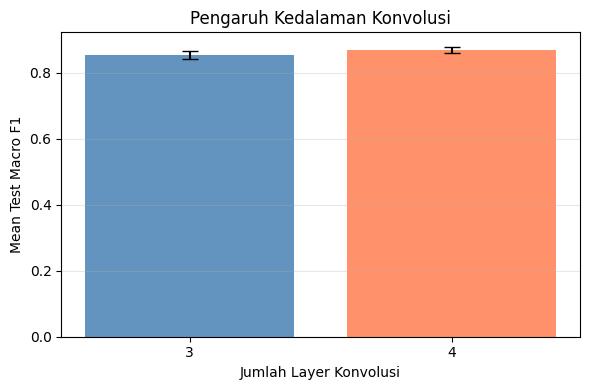

In [21]:
layer_analysis = (
    results_df.groupby("conv_layers")["test_macro_f1"]
    .agg(["mean", "std", "max", "min"])
    .reset_index()
)
print(layer_analysis.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    layer_analysis["conv_layers"].astype(str),
    layer_analysis["mean"],
    yerr=layer_analysis["std"],
    capsize=6, color=["steelblue", "coral"], alpha=0.85,
)
ax.set_xlabel("Jumlah Layer Konvolusi")
ax.set_ylabel("Mean Test Macro F1")
ax.set_title("Pengaruh Kedalaman Konvolusi")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "effect_conv_layers.png"), dpi=150, bbox_inches="tight")
plt.show()

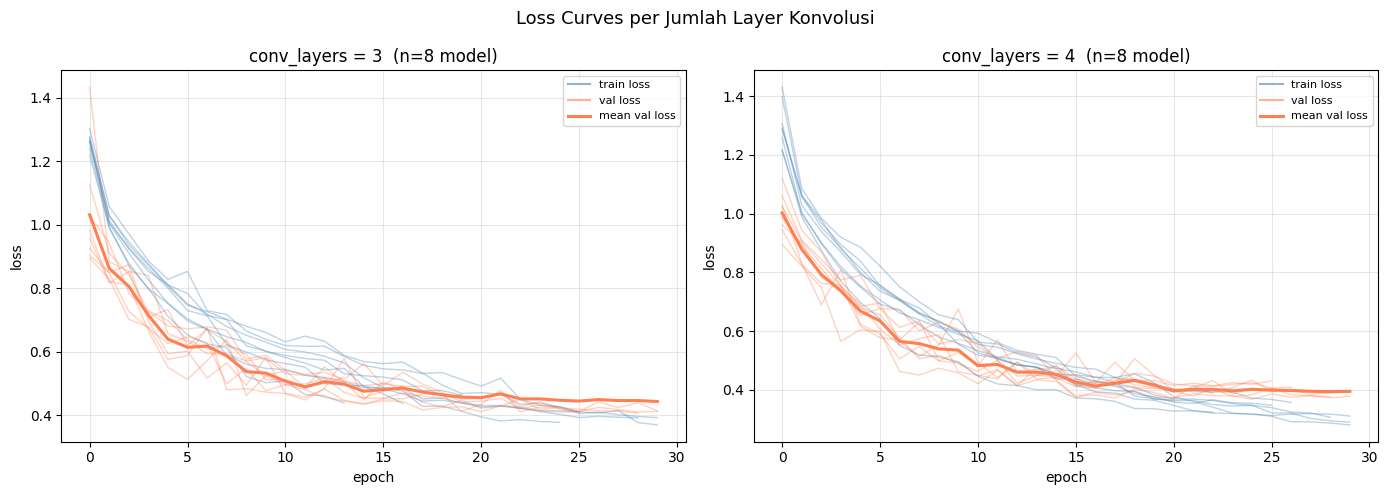

In [22]:
# loss curves dikelompokkan per nilai jumlah layer konvolusi
dim_col = "conv_layers"
dim_values = sorted(results_df[dim_col].unique())

fig, axes = plt.subplots(1, len(dim_values), figsize=(7 * len(dim_values), 5), sharey=False)
if len(dim_values) == 1:
    axes = [axes]

for ax, dim_val in zip(axes, dim_values):
    subset = results_df[results_df[dim_col] == dim_val]["model_name"].tolist()
    val_losses_all = []
    for model_name in subset:
        hist = load_history(str(HISTORIES_DIR / f"{model_name}.json"))
        tl = hist.get("loss", [])
        vl = hist.get("val_loss", [])
        if tl:
            ax.plot(tl, color="steelblue", alpha=0.35, linewidth=1.0)
        if vl:
            ax.plot(vl, color="coral", alpha=0.35, linewidth=1.0)
            val_losses_all.append(vl)
    # rata-rata val loss (padding dengan nilai terakhir)
    if val_losses_all:
        max_len = max(len(v) for v in val_losses_all)
        padded = np.array([v + [v[-1]] * (max_len - len(v)) for v in val_losses_all])
        ax.plot(padded.mean(axis=0), color="coral", linewidth=2.2, label="mean val loss")
    ax.set_title(f"conv_layers = {dim_val}  (n={len(subset)} model)")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend(
        handles=[
            plt.Line2D([0], [0], color="steelblue", alpha=0.6, label="train loss"),
            plt.Line2D([0], [0], color="coral", alpha=0.6, label="val loss"),
            plt.Line2D([0], [0], color="coral", linewidth=2.2, label="mean val loss"),
        ],
        fontsize=8,
    )
    ax.grid(True, alpha=0.3)

plt.suptitle("Loss Curves per Jumlah Layer Konvolusi", fontsize=13)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "loss_by_conv_layers.png"), dpi=150, bbox_inches="tight")
plt.show()


Model 4-layer rata-rata mencapai test macro F1 sekitar 0.869, unggul ~0.016 di atas kelompok 3-layer (rata-rata 0.852). Kedelapan posisi teratas di tabel semuanya ditempati model 4-layer, dan tidak ada satu pun model 3-layer yang melampaui model 4-layer mana pun.

Dengan empat layer konvolusi, jaringan bisa membangun representasi bertahap dari tepi dan tekstur di layer awal ke pola yang lebih abstrak di layer berikutnya. Untuk klasifikasi scene, perbedaan antara glacier dan mountain atau buildings dan street memang lebih mudah dipisahkan jika sudah diproses cukup dalam. Std F1 antar-model juga sedikit lebih kecil di kelompok 4-layer (sd=0.009 vs 0.011), meski dengan hanya 8 model per kelompok angka ini kurang cukup untuk kesimpulan kuat soal stabilitas.

### 2. Pengaruh Banyak Filter

filter_schedule     mean      std      max      min
      32-64-128 0.852974 0.009619 0.864927 0.845169
  32-64-128-256 0.867781 0.013642 0.879375 0.848084
     64-128-256 0.851827 0.016387 0.866096 0.828412
 64-128-256-512 0.869275 0.003970 0.872313 0.863730


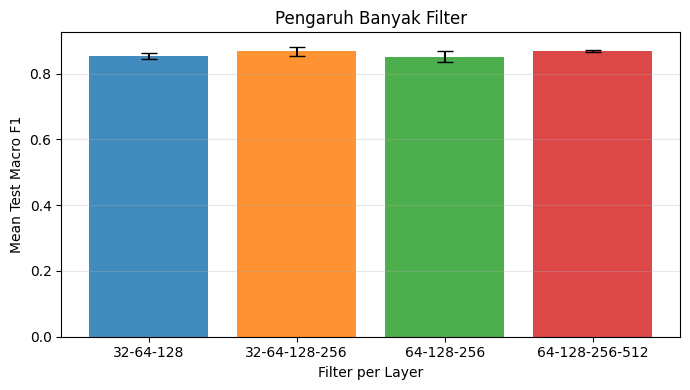

In [23]:
filter_analysis = (
    results_df.groupby("filter_schedule")["test_macro_f1"]
    .agg(["mean", "std", "max", "min"])
    .reset_index()
)
print(filter_analysis.to_string(index=False))

_n_bars = len(filter_analysis)
_colors = [plt.cm.tab10(i) for i in range(_n_bars)]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    filter_analysis["filter_schedule"],
    filter_analysis["mean"],
    yerr=filter_analysis["std"],
    capsize=6, color=_colors, alpha=0.85,
)
ax.set_xlabel("Filter per Layer")
ax.set_ylabel("Mean Test Macro F1")
ax.set_title("Pengaruh Banyak Filter")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "effect_filters.png"), dpi=150, bbox_inches="tight")
plt.show()

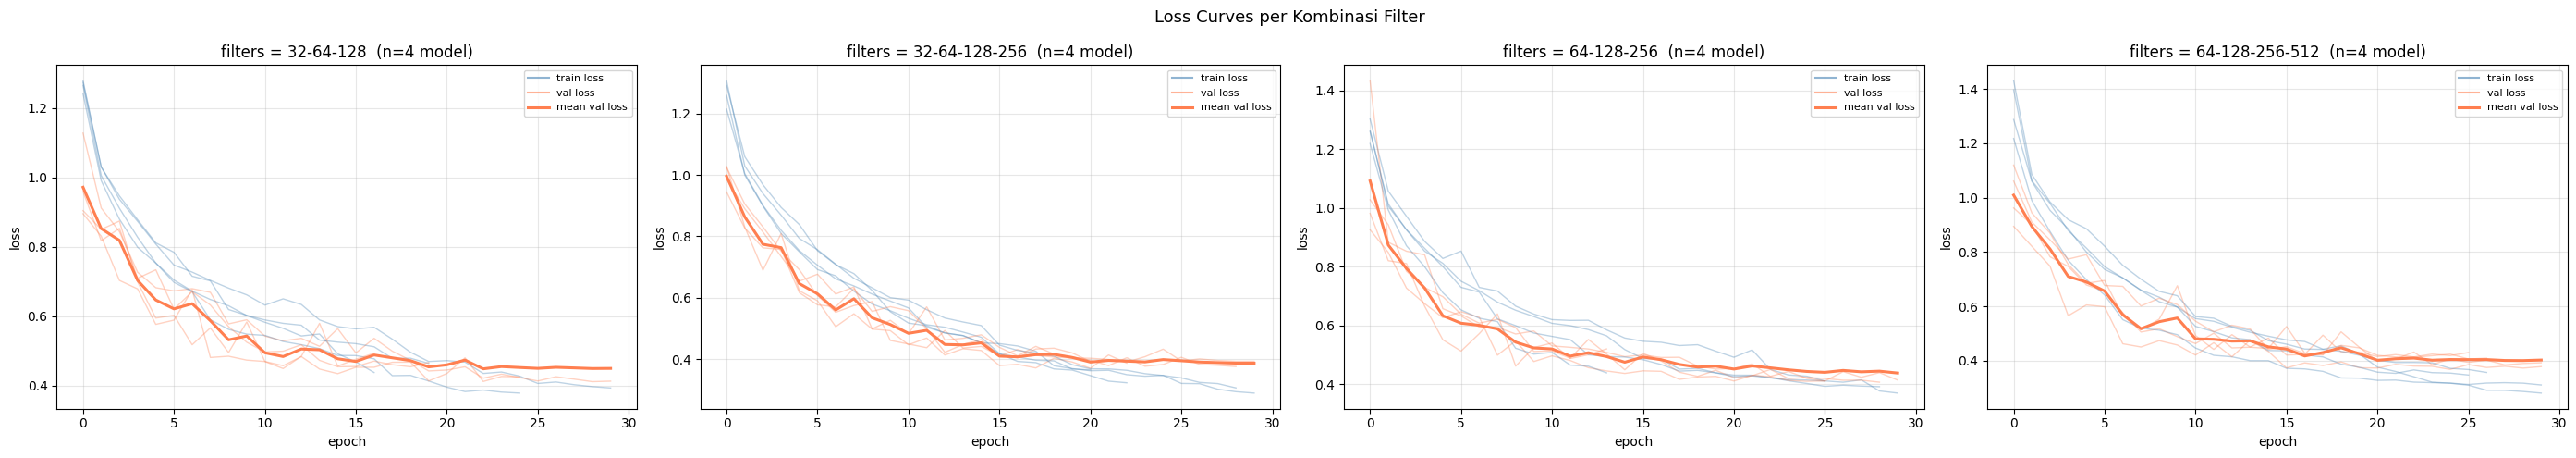

In [24]:
# loss curves dikelompokkan per kombinasi filter
dim_col = "filter_schedule"
dim_values = sorted(results_df[dim_col].unique())

fig, axes = plt.subplots(1, len(dim_values), figsize=(7 * len(dim_values), 5), sharey=False)
if len(dim_values) == 1:
    axes = [axes]

for ax, dim_val in zip(axes, dim_values):
    subset = results_df[results_df[dim_col] == dim_val]["model_name"].tolist()
    val_losses_all = []
    for model_name in subset:
        hist = load_history(str(HISTORIES_DIR / f"{model_name}.json"))
        tl = hist.get("loss", [])
        vl = hist.get("val_loss", [])
        if tl:
            ax.plot(tl, color="steelblue", alpha=0.35, linewidth=1.0)
        if vl:
            ax.plot(vl, color="coral", alpha=0.35, linewidth=1.0)
            val_losses_all.append(vl)
    if val_losses_all:
        max_len = max(len(v) for v in val_losses_all)
        padded = np.array([v + [v[-1]] * (max_len - len(v)) for v in val_losses_all])
        ax.plot(padded.mean(axis=0), color="coral", linewidth=2.2, label="mean val loss")
    ax.set_title(f"filters = {dim_val}  (n={len(subset)} model)")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend(
        handles=[
            plt.Line2D([0], [0], color="steelblue", alpha=0.6, label="train loss"),
            plt.Line2D([0], [0], color="coral", alpha=0.6, label="val loss"),
            plt.Line2D([0], [0], color="coral", linewidth=2.2, label="mean val loss"),
        ],
        fontsize=8,
    )
    ax.grid(True, alpha=0.3)

plt.suptitle("Loss Curves per Kombinasi Filter", fontsize=13)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "loss_by_filters.png"), dpi=150, bbox_inches="tight")
plt.show()


Model individual terbaik, `conv_L4_F32-64-128-256_K3_Pm`, menggunakan skema filter yang lebih kecil dengan hanya ~3 juta parameter, tapi mencapai test F1 0.879, melampaui semua model dengan filter 64-128-256-512 yang butuh lebih dari dua kali lipat parameter (6.86 juta). Ini sudah cukup menandakan bahwa jumlah filter bukan penentu utama performa di eksperimen ini.

Dilihat dari rata-rata per kelompok, selisihnya kecil. 
Pada 3-layer, 32-64-128 (mean 0.853) vs 64-128-256 (mean 0.852). 
Pada 4-layer, 32-64-128-256 (mean 0.868) vs 64-128-256-512 (mean 0.869). Hampir tidak ada perbedaan.

Kemungkinan penjelasannya adalah menambah filter meningkatkan kapasitas, tetapi juga memperlambat konvergensi dan butuh lebih banyak data agar efektif. Dengan ~11k sampel training dan early stopping yang sama, keuntungan kapasitas filter besar tidak sempat termanfaatkan. Kedalaman jaringan lebih efisien dalam hal ini karena setiap layer baru menambah satu blok konvolusi, bukan menggandakan koneksi di setiap layer yang sudah ada.

### 3. Pengaruh Ukuran Kernel

 kernel_size     mean      std      max      min
           3 0.855559 0.017436 0.879375 0.828412
           5 0.865369 0.005647 0.873067 0.856607


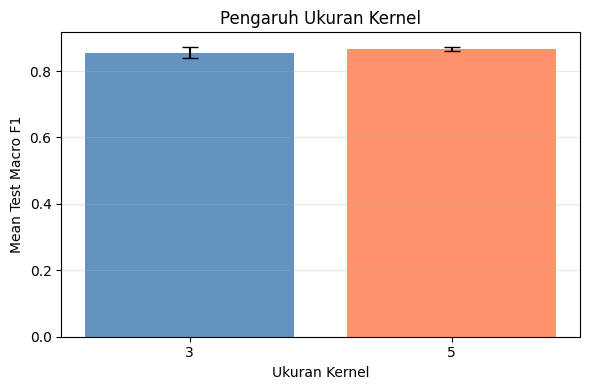

In [25]:
kernel_analysis = (
    results_df.groupby("kernel_size")["test_macro_f1"]
    .agg(["mean", "std", "max", "min"])
    .reset_index()
)
print(kernel_analysis.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    kernel_analysis["kernel_size"].astype(str),
    kernel_analysis["mean"],
    yerr=kernel_analysis["std"],
    capsize=6, color=["steelblue", "coral"], alpha=0.85,
)
ax.set_xlabel("Ukuran Kernel")
ax.set_ylabel("Mean Test Macro F1")
ax.set_title("Pengaruh Ukuran Kernel")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "effect_kernel_size.png"), dpi=150, bbox_inches="tight")
plt.show()

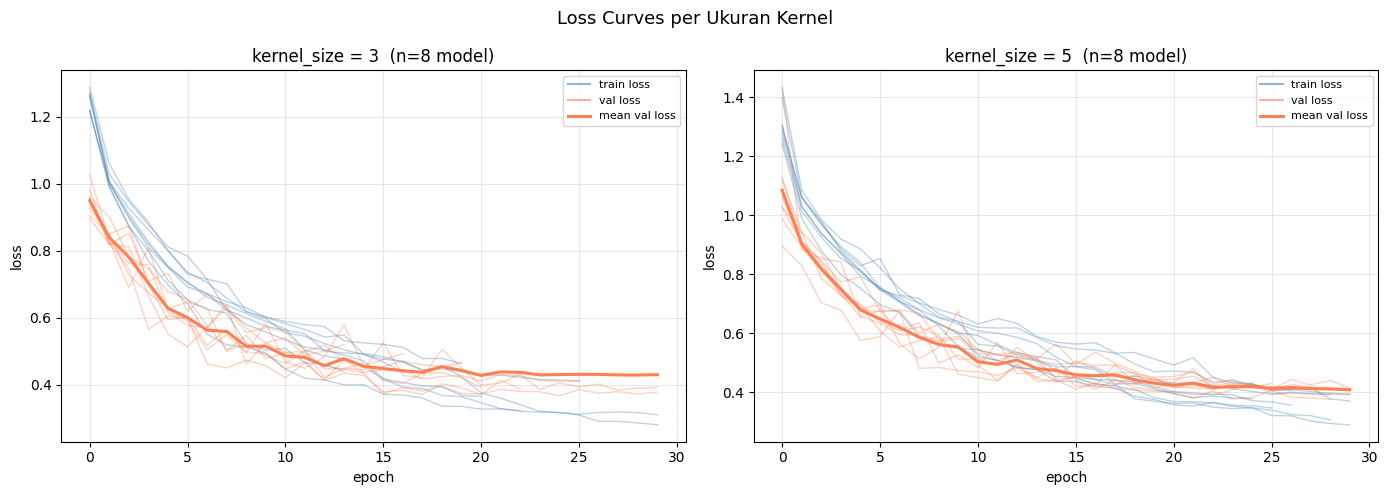

In [ ]:
# loss curves dikelompokkan per ukuran kernel
dim_col = "kernel_size"
dim_values = sorted(results_df[dim_col].unique())

fig, axes = plt.subplots(1, len(dim_values), figsize=(7 * len(dim_values), 5), sharey=False)
if len(dim_values) == 1:
    axes = [axes]

for ax, dim_val in zip(axes, dim_values):
    subset = results_df[results_df[dim_col] == dim_val]["model_name"].tolist()
    val_losses_all = []
    for model_name in subset:
        hist = load_history(str(HISTORIES_DIR / f"{model_name}.json"))
        tl = hist.get("loss", [])
        vl = hist.get("val_loss", [])
        if tl:
            ax.plot(tl, color="steelblue", alpha=0.35, linewidth=1.0)
        if vl:
            ax.plot(vl, color="coral", alpha=0.35, linewidth=1.0)
            val_losses_all.append(vl)
    if val_losses_all:
        max_len = max(len(v) for v in val_losses_all)
        padded = np.array([v + [v[-1]] * (max_len - len(v)) for v in val_losses_all])
        ax.plot(padded.mean(axis=0), color="coral", linewidth=2.2, label="mean val loss")
    ax.set_title(f"kernel_size = {dim_val}  (n={len(subset)} model)")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend(
        handles=[
            plt.Line2D([0], [0], color="steelblue", alpha=0.6, label="train loss"),
            plt.Line2D([0], [0], color="coral", alpha=0.6, label="val loss"),
            plt.Line2D([0], [0], color="coral", linewidth=2.2, label="mean val loss"),
        ],
        fontsize=8,
    )
    ax.grid(True, alpha=0.3)

plt.suptitle("Loss Curves per Ukuran Kernel", fontsize=13)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "loss_by_kernel_size.png"), dpi=150, bbox_inches="tight")
plt.show()


Rata-rata test macro F1 kernel 5x5 (0.865) sedikit di atas kernel 3x3 (0.856), selisih ~0.009. Kernel lebih besar punya receptive field langsung yang lebih luas, berguna untuk menangkap pola berukuran menengah seperti tekstur bangunan atau pola vegetasi dalam satu langkah konvolusi.

Tapi model terbaik berdasarkan val F1, `conv_L4_F64-128-256-512_K3_Pa` (val F1 0.887), justru menggunakan kernel 3x3. Dengan 4 layer konvolusi, receptive field efektif sudah cukup lebar meski kernel kecil, karena setiap layer menambah konteks spasial secara bertahap. Dari sisi komputasi, kernel 3x3 juga lebih hemat, $3^2 = 9$ bobot per filter per channel dibanding $5^2 = 25$. Keunggulan rata-rata kernel 5x5 ada, tapi tidak cukup besar untuk dijadikan alasan utama memilihnya jika kedalaman jaringan sudah memadai.

### 4. Pengaruh Jenis Pooling

pooling     mean      std      max      min
average 0.860239 0.010644 0.872313 0.845169
    max 0.860689 0.016658 0.879375 0.828412


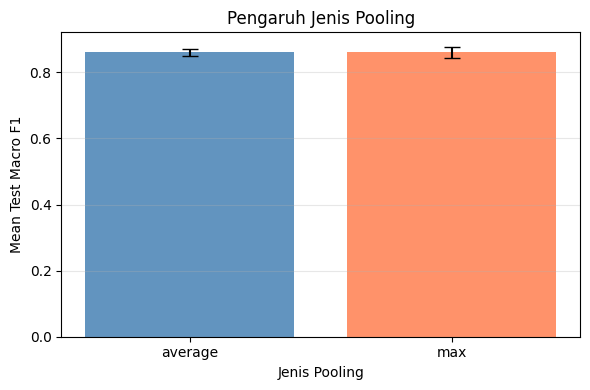

In [27]:
pooling_analysis = (
    results_df.groupby("pooling")["test_macro_f1"]
    .agg(["mean", "std", "max", "min"])
    .reset_index()
)
print(pooling_analysis.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    pooling_analysis["pooling"],
    pooling_analysis["mean"],
    yerr=pooling_analysis["std"],
    capsize=6, color=["steelblue", "coral"], alpha=0.85,
)
ax.set_xlabel("Jenis Pooling")
ax.set_ylabel("Mean Test Macro F1")
ax.set_title("Pengaruh Jenis Pooling")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "effect_pooling.png"), dpi=150, bbox_inches="tight")
plt.show()

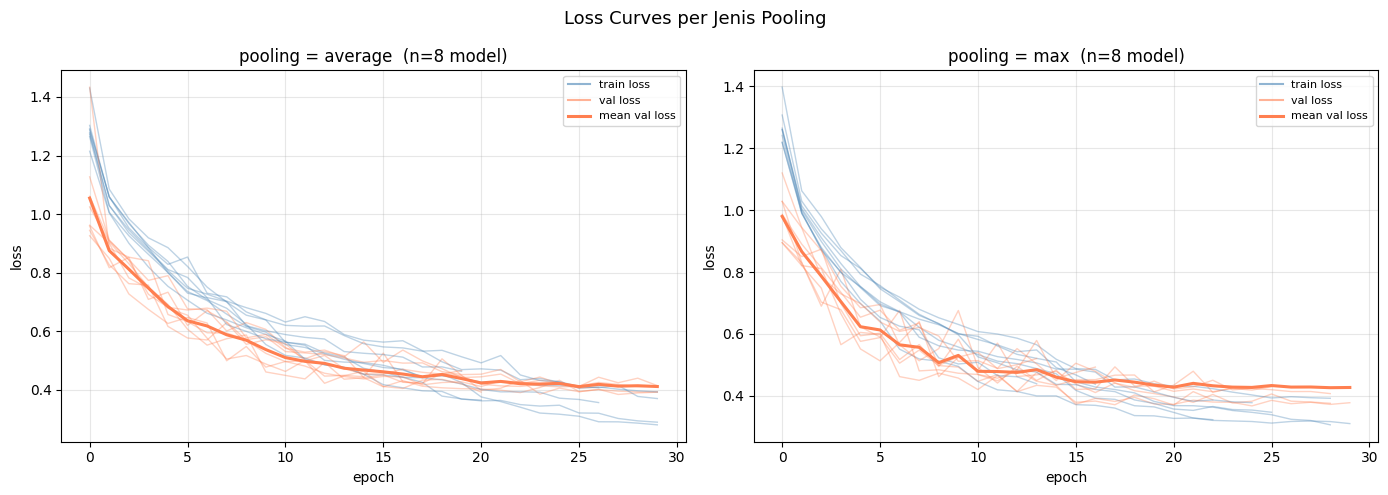

In [28]:
# loss curves dikelompokkan per jenis pooling
dim_col = "pooling"
dim_values = sorted(results_df[dim_col].unique())

fig, axes = plt.subplots(1, len(dim_values), figsize=(7 * len(dim_values), 5), sharey=False)
if len(dim_values) == 1:
    axes = [axes]

for ax, dim_val in zip(axes, dim_values):
    subset = results_df[results_df[dim_col] == dim_val]["model_name"].tolist()
    val_losses_all = []
    for model_name in subset:
        hist = load_history(str(HISTORIES_DIR / f"{model_name}.json"))
        tl = hist.get("loss", [])
        vl = hist.get("val_loss", [])
        if tl:
            ax.plot(tl, color="steelblue", alpha=0.35, linewidth=1.0)
        if vl:
            ax.plot(vl, color="coral", alpha=0.35, linewidth=1.0)
            val_losses_all.append(vl)
    if val_losses_all:
        max_len = max(len(v) for v in val_losses_all)
        padded = np.array([v + [v[-1]] * (max_len - len(v)) for v in val_losses_all])
        ax.plot(padded.mean(axis=0), color="coral", linewidth=2.2, label="mean val loss")
    ax.set_title(f"pooling = {dim_val}  (n={len(subset)} model)")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend(
        handles=[
            plt.Line2D([0], [0], color="steelblue", alpha=0.6, label="train loss"),
            plt.Line2D([0], [0], color="coral", alpha=0.6, label="val loss"),
            plt.Line2D([0], [0], color="coral", linewidth=2.2, label="mean val loss"),
        ],
        fontsize=8,
    )
    ax.grid(True, alpha=0.3)

plt.suptitle("Loss Curves per Jenis Pooling", fontsize=13)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "loss_by_pooling.png"), dpi=150, bbox_inches="tight")
plt.show()


Max pooling dan average pooling menghasilkan performa yang hampir identik di seluruh 16 model. Mean test F1 sekitar 0.861 vs 0.860, tanpa pola yang konsisten di dalam tiap subkelompok arsitektur.

Max pooling mempertahankan aktivasi paling kuat per region, sedangkan average pooling merata-rata seluruh area. Untuk scene classification, di mana sinyal kelas tersebar luas di gambar dan tidak terkonsentrasi di satu titik, perbedaan antara kedua operasi ini tampaknya tidak terlalu relevan. Dari 16 kombinasi yang diuji, tidak ada yang menunjukkan satu jenis pooling selalu lebih baik dari yang lain.

### 5. Loss Curve 16 Model Conv2D

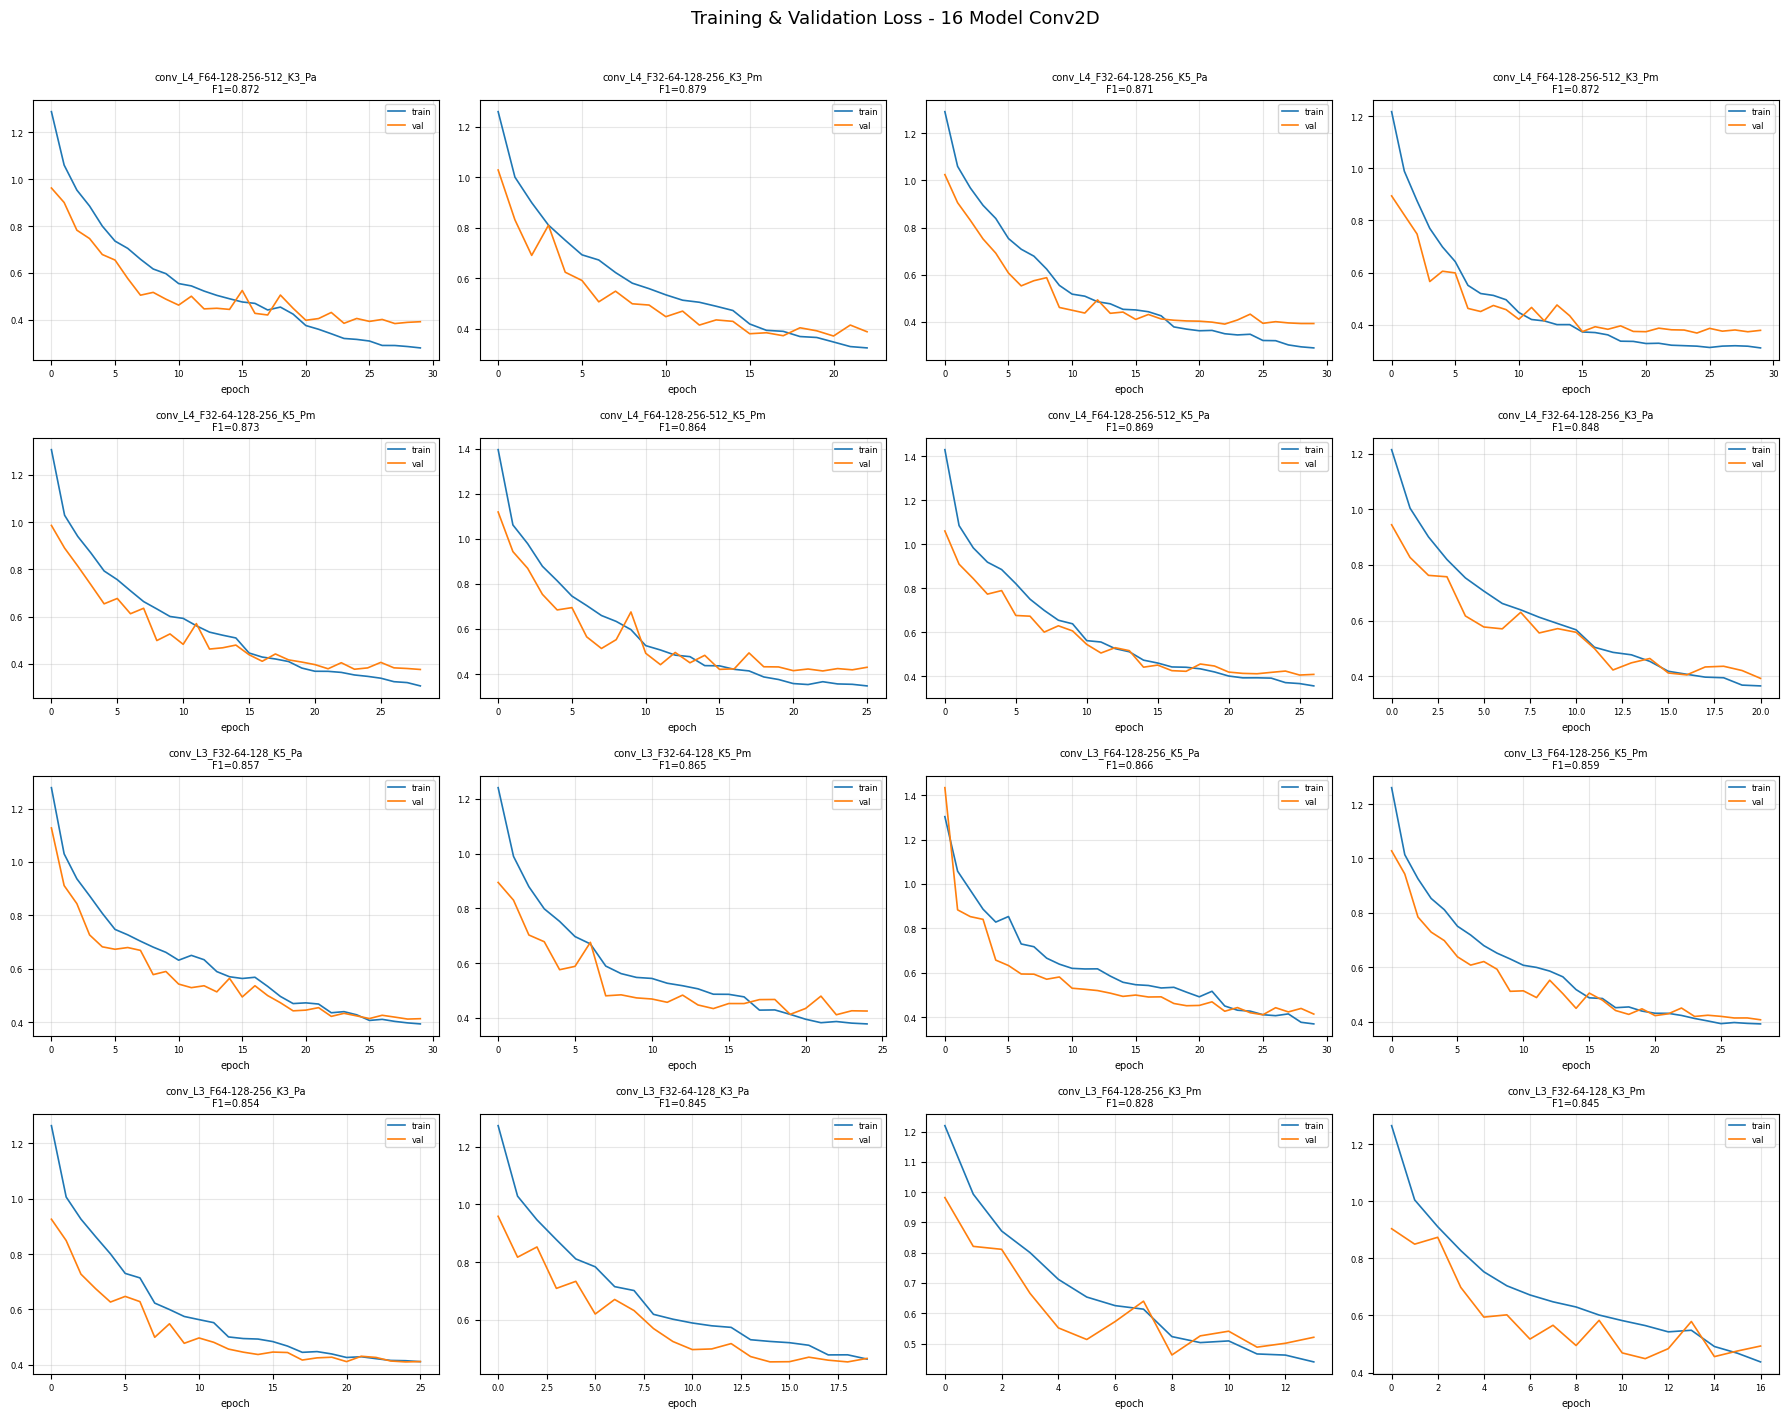

In [29]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes_flat = axes.flatten()

model_names_sorted = results_df["model_name"].tolist()

for idx, model_name in enumerate(model_names_sorted):
    ax = axes_flat[idx]
    history_path = HISTORIES_DIR / f"{model_name}.json"
    if not history_path.exists():
        ax.set_visible(False)
        continue
    hist = load_history(str(history_path))
    if "loss" in hist:
        ax.plot(hist["loss"], label="train", linewidth=1.2)
    if "val_loss" in hist:
        ax.plot(hist["val_loss"], label="val", linewidth=1.2)
    row = results_df[results_df["model_name"] == model_name]
    f1_str = f"F1={row['test_macro_f1'].values[0]:.3f}" if len(row) else ""
    ax.set_title(f"{model_name}\n{f1_str}", fontsize=7)
    ax.set_xlabel("epoch", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

plt.suptitle("Training & Validation Loss - 16 Model Conv2D", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "loss_curves_all_conv2d.png"), dpi=120, bbox_inches="tight")
plt.show()

Dari 16 loss curve, sebagian besar menunjukkan pola training yang sehat. Training loss turun bertahap dan validation loss mengikuti tanpa divergensi besar. Dropout 0.5 dan early stopping tampaknya cukup efektif menekan overfitting.

Perbedaan paling terlihat ada di durasi training. Model 3-layer dengan kernel 3x3 cenderung distop early stopping lebih awal, di kisaran epoch 10-15, sementara model 4-layer rata-rata berjalan lebih panjang sebelum plateau. Model 3-layer sepertinya cepat stagnan bukan karena overfitting, tapi karena kapasitasnya sudah habis lebih cepat. Ini sejalan dengan hasil F1 yang lebih rendah pada kelompok 3-layer.

### 6. Perbandingan Keras vs Implementasi NumPy

implementasi  macro_f1  waktu_s
       Keras    0.8723    3.909
       NumPy    0.8723  145.937

Prediction agreement: 100.00%
(Dievaluasi pada 3000 sampel test)


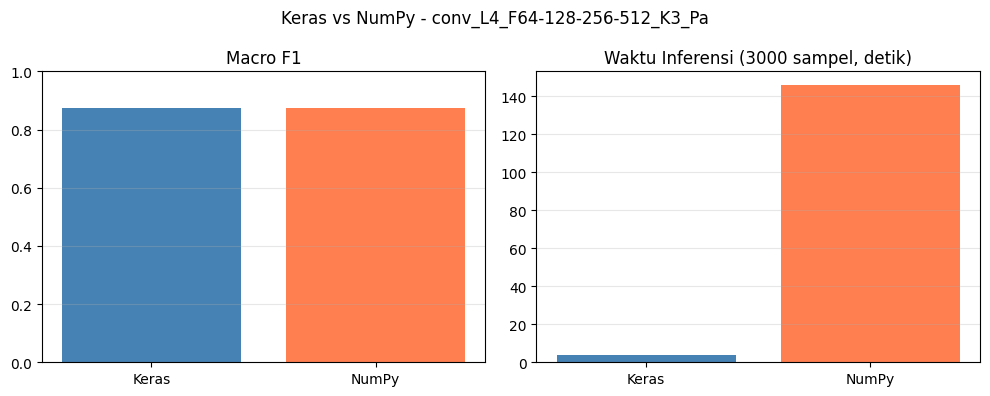

In [30]:
kv = keras_vs_numpy
comparison_df = pd.DataFrame([
    {"implementasi": "Keras",  "macro_f1": kv["keras_macro_f1_full"], "waktu_s": kv["keras_full_time_s"]},
    {"implementasi": "NumPy",  "macro_f1": kv["numpy_macro_f1_full"], "waktu_s": kv["numpy_time_s"]},
])
print(comparison_df.to_string(index=False))
print(f"\nPrediction agreement: {kv['prediction_agreement_pct']:.2f}%")
print(f"(Dievaluasi pada {kv['eval_samples']} sampel test)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(comparison_df["implementasi"], comparison_df["macro_f1"], color=["steelblue", "coral"])
axes[0].set_title("Macro F1")
axes[0].set_ylim(0, 1)
axes[0].grid(True, axis="y", alpha=0.3)
axes[1].bar(comparison_df["implementasi"], comparison_df["waktu_s"], color=["steelblue", "coral"])
axes[1].set_title(f"Waktu Inferensi ({kv['eval_samples']} sampel, detik)")
axes[1].grid(True, axis="y", alpha=0.3)
plt.suptitle(f"Keras vs NumPy - {best_model_name}")
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "keras_vs_numpy_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

Pada seluruh 3000 sampel test, prediksi NumPy dan Keras identik 100%, dengan macro F1 sama persis di 0.8723. Ini mengonfirmasi bahwa bobot berhasil dipindahkan dengan benar dan operasi forward pass diimplementasikan sesuai perilaku Keras, termasuk konvolusi, pooling, flatten, dan dense. Dropout dinonaktifkan saat inferensi di kedua implementasi.

Dari sisi waktu, Keras selesai dalam 3.91 detik, NumPy butuh 145.94 detik, sekitar 37 kali lebih lambat. Gap ini wajar, karena Keras memanfaatkan GPU via CUDA dengan operasi paralel, sedangkan implementasi NumPy berjalan di CPU secara serial tanpa optimasi khusus.

### 7. Conv2D Shared vs LocallyConnected2D Non-Shared

                     arsitektur implementasi filter_schedule  test_macro_f1  parameter_count
                Conv2D (shared)        Keras  64-128-256-512       0.872313          6860294
LocallyConnected2D (non-shared)        Keras  64-128-256-512       0.049645        235111302


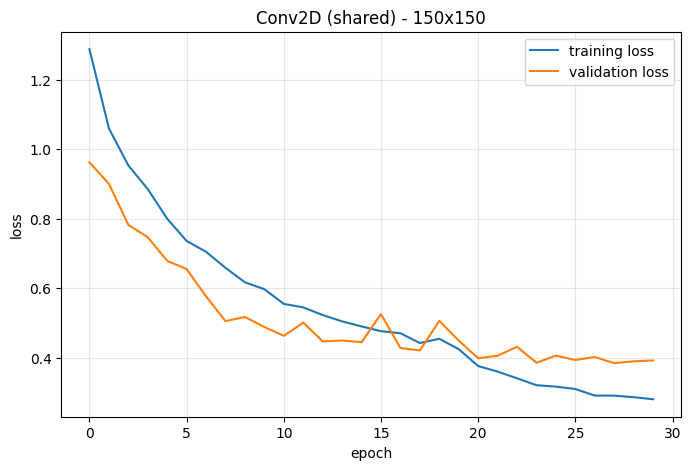

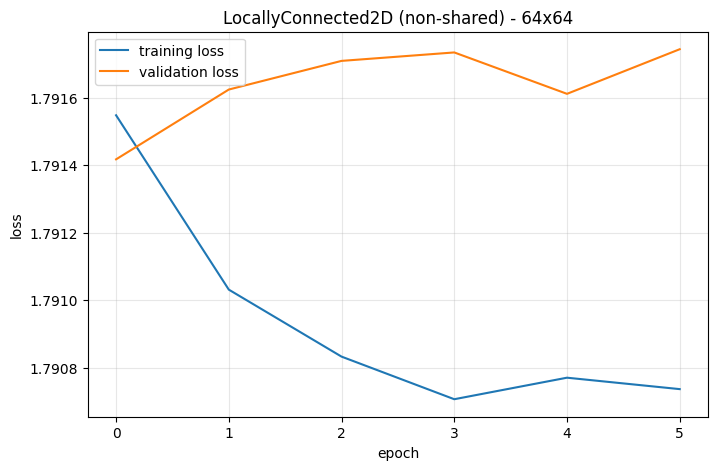

In [31]:

# perbandingan shared vs non-shared menggunakan F1 Keras agar apple-to-apple
shared_record = {
    "arsitektur": "Conv2D (shared)",
    "implementasi": "Keras",
    "input_size": f"{IMG_SIZE[0]}x{IMG_SIZE[1]}",
    "test_macro_f1": float(best_row["test_macro_f1"]),
    "parameter_count": int(best_row["parameter_count"]),
    "model_name": best_model_name,
    "filter_schedule": best_filter_schedule,
    "dense_units": best_dense_units,
    "dropout_rate": best_dropout_rate,
}
non_shared_record = {
    "arsitektur": "LocallyConnected2D (non-shared)",
    "implementasi": "Keras",
    "input_size": f"{IMG_SIZE_LC[0]}x{IMG_SIZE_LC[1]}",
    "test_macro_f1": float(lc2d_keras_f1),
    "parameter_count": int(lc2d_params),
    "model_name": lc2d_model_name,
    "filter_schedule": best_filter_schedule,
    "dense_units": best_dense_units,
    "dropout_rate": best_dropout_rate,
}
comparison_shared_df = pd.DataFrame([shared_record, non_shared_record])
print(comparison_shared_df[["arsitektur", "implementasi", "filter_schedule", "test_macro_f1", "parameter_count"]].to_string(index=False))

hist_shared = load_history(str(HISTORIES_DIR / f"{best_model_name}.json"))
fig_shared = plot_loss_history(
    hist_shared,
    save_path=str(REPORTS_DIR / "loss_shared_best.png"),
    title=f"Conv2D (shared) - {IMG_SIZE[0]}x{IMG_SIZE[1]}",
)
plt.show()

fig_lc2d = plot_loss_history(
    lc2d_history,
    save_path=str(REPORTS_DIR / "loss_lc2d.png"),
    title=f"LocallyConnected2D (non-shared) - {IMG_SIZE_LC[0]}x{IMG_SIZE_LC[1]}",
)
plt.show()

save_json(comparison_shared_df.to_dict(orient="records"), str(REPORTS_DIR / "shared_vs_nonshared.json"))


Conv2D (shared) mencapai test macro F1 0.872 dengan 6.86 juta parameter. LC2D (non-shared) gagal konvergen dengan F1 hanya 0.050 meski memiliki 235 juta parameter, sekitar 34 kali lebih banyak. Angka 0.050 bahkan di bawah tebakan acak uniform untuk 6 kelas ($\frac{1}{6} \approx 0.167$), artinya model tidak belajar sama sekali.

Log training memperjelas kondisi ini. val accuracy tidak bergerak dari 17.1% selama 6 epoch penuh sebelum early stopping aktif. Gradiennya tampaknya tidak menghasilkan update yang berarti, kemungkinan karena 235 juta parameter terlalu banyak untuk dioptimasi dari hanya ~11k sampel training.

Di sinilah parameter sharing jadi penting. Conv2D memaksa satu set filter berlaku di semua posisi spasial, dengan asumsi bahwa fitur yang berguna di satu lokasi gambar juga relevan di lokasi lain. Ini juga mempermudah optimasi karena setiap filter belajar dari lebih banyak contoh. Tanpa sharing, setiap posisi output harus belajar filternya sendiri dari nol, dan dengan grid output 64x64 ditambah 4 layer filter besar, hasilnya sudah terlihat di sini.

## Export Artefak

In [ ]:
import os
from IPython.display import FileLink

!zip -r artifacts.zip /kaggle/working/ooooo/artifacts
FileLink(r'artifacts.zip')